In [1]:
# Code to test everything is working fine. 
import os 
import sys
sys.path.append("../../")


import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from torch.utils.data import DataLoader, Dataset

from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE 
from vi_rnn.utils import *
from vi_rnn.evaluation import * 
from vi_rnn.saving import save_model, load_model
from vi_rnn.datasets import DTTDataset

from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from py_rnn.default_params import get_default_params

import pandas as pd 

from sklearn.model_selection import train_test_split

from data.utils import * 

from evaluation.calc_stats import calc_isi_stats
from scipy.signal import convolve, gaussian
%matplotlib inline

### Load spikes and neuromodulation signal

In [2]:
data_dir = '../../data/recordings/nk341_mPFC/' 
out_dir = "../../models/dtt/" 

sampling_rate = 30_000 # khz
t_start_baseline, t_end_baseline = 10, 600
t_start_post_trial, t_end_post_trial = 6_969, 7_869
bin_size = 0.02
bs = 256 # batch size 

deconvolve = False
convolve_spikes = True  
z_score = False 
center = False 

In [3]:
def load_data():
    spikes = []

    spikes_dir = os.path.join(data_dir, 'spikes')

    t_start, t_end = 10, 0
    for f in os.listdir(spikes_dir):
        spikes_df = pd.read_csv(f'{spikes_dir}/{f}', header=None)
        spikes.append(spikes_df.to_numpy().flatten() / sampling_rate)
        t_end = max(t_end, int(np.ceil(spikes[-1].max())))

    print(f't_end = {t_end}')
    spike_counts = np.zeros((len(spikes), int((t_end - t_start) / bin_size)))
    for i in range(len(spikes)):
        spike_counts[i], _ = bin_spike_train(spikes[i], t_start, t_end, bin_size)

    # load neuromodulation signal 
    neuromod_dir = os.path.join(data_dir, 'neuromodulators')
    if deconvolve:
        lc_neuromod = pd.read_csv(f'{neuromod_dir}/norepinephrine_deconvolved.csv', header=None).to_numpy().flatten()
    else:
        lc_neuromod = pd.read_csv(f'{neuromod_dir}/norepinephrine.csv', header=None).to_numpy().flatten()

    # center 
    if center: 
        lc_neuromod += np.abs(lc_neuromod.min())
    # z-score 
    if z_score:
        neuromod_activity = (lc_neuromod - lc_neuromod.mean()) / lc_neuromod.std()
    else: neuromod_activity = lc_neuromod
    if convolve_spikes:
        kernel_size = 100
        sigma = 10
        
        gaussian_kernel = gaussian(kernel_size, sigma) 
        # Make it causal: Zero out future values
        # gaussian_kernel[:kernel_size // 2] = 0
        gaussian_kernel /= gaussian_kernel.sum()
        plt.plot(gaussian_kernel)
        smoothed_spikes = []
        for n in range(spike_counts.shape[0]):
            smoothed_spikes.append(convolve(spike_counts[n], gaussian_kernel, mode='full'))
        spike_counts = np.array(smoothed_spikes)
        
    # load trials info 
    trials_dir = os.path.join(data_dir, 'trials') 
    trials_df = pd.read_csv(os.path.join(trials_dir, 'trials.csv'))

    return spikes, spike_counts, neuromod_activity, trials_df 

t_end = 7889


C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_31904\4153991306.py:35: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  gaussian_kernel = gaussian(kernel_size, sigma)


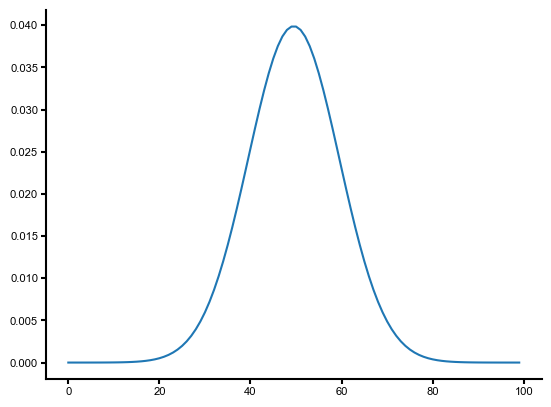

In [4]:
spikes, spike_counts, neuromod_activity, trials_df = load_data()

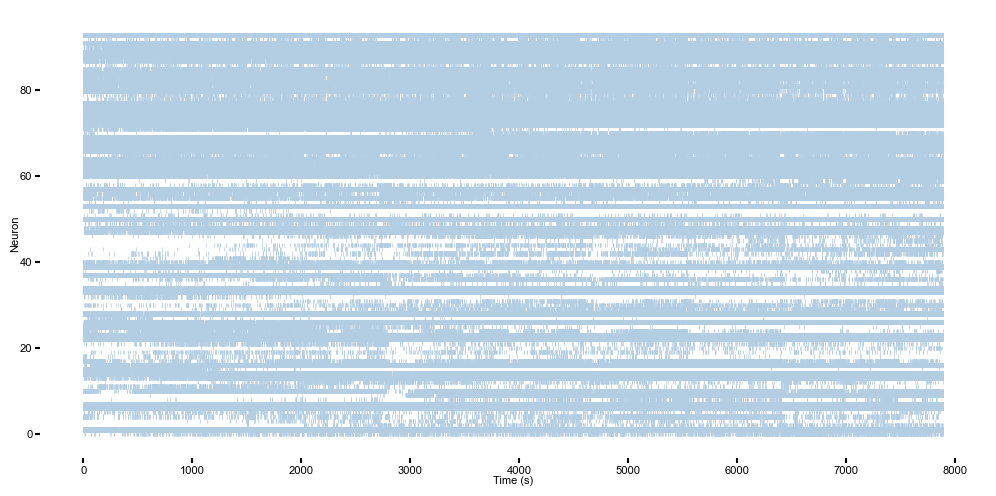

In [5]:
cmap = mpl.colormaps["Pastel1"]
color = cmap(1)
plt.figure(figsize=(10, 5))
plt.eventplot(spikes, linewidths=0.5, colors=color) 
plt.xlabel("Time (s)")
plt.ylabel("Neuron")

# hide the right and top spines
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.tight_layout()

In [6]:
trials_df.head()

,id,t,trialtype,cs,us,vacuum,opto_on,opto_off,ustype,us_stop,cstype,first_lick
0,1,630.818133,ODOR-ON_1,NaN,631.343300,NaN,NaN,NaN,Odor,641.322667,NaN,631.344
1,2,671.726933,ODOR-ON_1,NaN,672.246433,NaN,NaN,NaN,Odor,682.248533,NaN,NaN
2,3,712.516267,ODOR-ON_1,NaN,713.060933,NaN,NaN,NaN,Odor,723.054933,NaN,NaN
3,4,753.399467,PAUSE_120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,875.153067,TONE_1_LAG_500_REW_1_LAG_2000_VACUUM_1,875.656533,877.389600,879.399833,NaN,NaN,REW_1,NaN,NaN,880.039


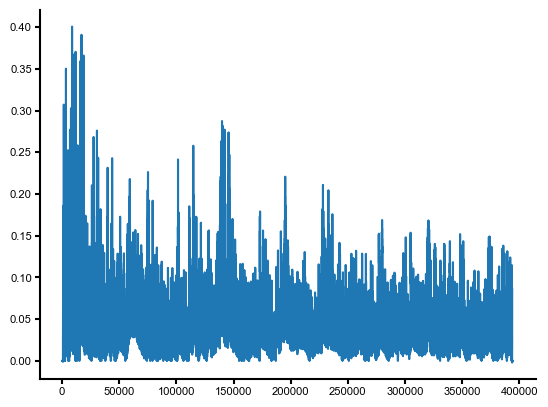

In [7]:
plt.plot(neuromod_activity)

### Split baseline period into training and testing samples and filter out neurons with little activity

In [8]:
trials_dir = os.path.join(data_dir, 'trials') 
trials_df = pd.read_csv(os.path.join(trials_dir, 'trials.csv'))

In [9]:
def get_block(spike_counts, neuromod_activity, t_start, t_end):
    block_dur = int((t_end - t_start) / bin_size)
    block_start_idx = int(t_start / bin_size) 
    spike_counts_block = spike_counts[:, block_start_idx:block_start_idx + block_dur]
    s_block = neuromod_activity[block_start_idx:block_start_idx + block_dur]
    return spike_counts_block, s_block 

#### Get first 10 minutes block

In [10]:
# spike_counts_baseline, s_baseline = get_block(spike_counts, neuromod_activity, t_start_baseline, t_end_baseline)
# dur_baseline = s_baseline.shape[0]
# print(dur_baseline)
# #divide into train and test samples 
# train_size_baseline = int(dur_baseline * 0.75)
# test_size_baseline = dur_baseline - train_size_baseline
# print(f'Train sample size: {train_size_baseline}')
# print(f'Test sample size: {test_size_baseline}')

# train_samples = spike_counts_baseline[:, :train_size_baseline]
# test_samples = spike_counts_baseline[:, train_size_baseline:]
# s_train = s_baseline[:train_size_baseline]
# s_test = s_baseline[train_size_baseline:]

#### Get last 20 minutes block

In [11]:
spike_counts_pt_baseline, s_pt_baseline = get_block(spike_counts, neuromod_activity, t_start_post_trial, t_end_post_trial)
dur_pt_baseline = s_pt_baseline.shape[0]
print(dur_pt_baseline)
spike_counts_pt_baseline = (spike_counts_pt_baseline - spike_counts_pt_baseline.mean()) / spike_counts_pt_baseline.std()
#divide into train and test samples 
train_size_pt_baseline = int(dur_pt_baseline * 0.75)
test_size_pt_baseline = dur_pt_baseline - train_size_pt_baseline
print(f'Train sample size: {train_size_pt_baseline}')
print(f'Test sample size: {dur_pt_baseline - train_size_pt_baseline}')

train_samples_pt = spike_counts_pt_baseline[:, :train_size_pt_baseline]
test_samples_pt = spike_counts_pt_baseline[:, train_size_pt_baseline:]
s_train_pt = s_pt_baseline[:train_size_pt_baseline]
s_test_pt = s_pt_baseline[train_size_pt_baseline:]

45000
Train sample size: 33750
Test sample size: 11250


In [12]:
# seq_periods = [[0, train_size_baseline], [train_size_baseline, train_size_baseline + train_size_pt_baseline]]
# seq_periods_eval = [[0, test_size_baseline], [test_size_baseline, test_size_baseline + test_size_pt_baseline]]

# train_samples = np.hstack([train_samples, train_samples_pt])
# test_samples = np.hstack([test_samples, test_samples_pt])
# s_train = np.hstack([s_train, s_train_pt])
# s_test = np.hstack([s_test, s_test_pt])
seq_periods = [[0, train_size_pt_baseline]]
seq_periods_eval = [[0, test_size_pt_baseline]]

train_samples = train_samples_pt
test_samples = test_samples_pt 
s_train = s_train_pt 
s_test = s_test_pt 

In [13]:
s_test.shape

(11250,)

#### Get airpuff blocks

In [14]:
trials_df['t'] *= 50
airpuff_trial_times = trials_df[trials_df['trialtype'] == 'TONE_3_LAG_500_AIRPUFF_1']['t'].astype('int').to_list()
print(airpuff_trial_times)

[145744, 148534, 151322, 191356, 194143, 196935]


In [15]:
# for each trial time, get a 20s block of neural and neuromodulatory activity
for t in airpuff_trial_times:
    t_s = t / 50.0 #convert back to seconds 
    t_start, t_end = t_s - 10, t_s + 10
    spike_counts_airpuff, s_airpuff = get_block(spike_counts, neuromod_activity, t_start, t_end) 
    # z-score 
    spike_counts_airpuff = (spike_counts_airpuff - spike_counts_airpuff.mean()) / spike_counts_airpuff.std()
    seq_len = spike_counts_airpuff.shape[1]
    print(t_start, t_end, seq_len)
    # append to test samples
    test_samples = np.hstack([test_samples, spike_counts_airpuff])
    s_test = np.hstack([s_test, s_airpuff])
    prev_seq_idx = seq_periods_eval[-1][1]
    seq_periods_eval.append([prev_seq_idx, prev_seq_idx + seq_len])

2904.88 2924.88 1000
2960.68 2980.68 1000
3016.44 3036.44 1000
3817.12 3837.12 1000
3872.86 3892.86 1000
3928.7 3948.7 1000


In [16]:
s_test.shape, test_samples.shape

((17250,), (94, 17250))

In [17]:
task_params = {
            "dur": 100,
            "n_trials": 12000,
            "name": "",
            "dataset_name": data_dir,
        }
task = DTTDataset(task_params, 
    train_samples.T, 
    s_train=s_train, 
    s_test=s_test,
    seq_periods=seq_periods,
    seq_periods_eval=seq_periods_eval,
    data_eval=test_samples.T)

In [18]:
task.s_test.shape

torch.Size([1, 17250])

### Load models

In [17]:
models = {}
neuromodulation = ['None', 'additive', 'postsynaptic']
ranks = [3] 
N_counts = [94, 256]
filters = ['', '_deconvolved', '_centered_nzsc']

for neuromod in neuromodulation:
    for rank in ranks:
        for N in N_counts:
            for filter in filters:
                if neuromod == 'None' and filter != '': continue 
                try:
                    vae, params, task_params, training_params = load_model(f'../../models/dtt/dtt_{neuromod}_rank_{rank}_{N}{filter}')
                    models[(neuromod, rank, N, filter)] = vae

                except: 
                    print(f'Not found: {neuromod, rank, N, filter}')            

# vae, params, task_params, training_params = load_model(f'../../models/dtt/dtt_postsynaptic_rank_{rank}_94_centered_nzsc')
# models[('postsynaptic', rank, N, '_centered_nzsc')] = vae

# vae, params, task_params, training_params = load_model(f'../../models/dtt/dtt_additive_rank_3_94_deconvolved')            
# models[('additive', 3, 94, 'deconvolved')] = vae
# vae, params, task_params, training_params = load_model(f'../../models/dtt/dtt_additive_rank_3_94')            
# models[('additive', 3, 94, 'calcium')] = vae



dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using ReLU activation
using uniform init
weight scaler 1
using acausal constant padding
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using ReLU activation
using uniform init
weight scaler 1
using acausal constant padding
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: additive
using ReLU activation
using uniform init
weight scaler 1
using acausal constant padding
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: additive
using ReLU activation
using uniform init
weight scaler 1
using acausal constant padding
dict_keys(['dim_x', 'dim_z',

In [21]:
models = {}
vae, params, task_params, training_params = load_model(f'../../models/dtt/dtt_additive_rank_3_94_gauss')
models[('additive', 3, 94, 'gauss')] = vae 
vae, params, task_params, training_params = load_model(f'../../models/dtt/dtt_None_rank_3_94_gauss')
models[('None', 3, 94, 'gauss')] = vae 


dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: additive
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1


### 2. Baseline evaluation

#### 2.1. Generate spikes for baseline testing period

In [22]:
spike_preds = {}

for model in models.keys():
    neuromod, rank, N, filtered = model 
    print(neuromod, rank, N)
    vae = models[model]
    for i, block in enumerate(task.seq_periods_eval):
        block_start = block[0]
        block_end = block[1] 
        T = block_end - block_start 
        z_hat, _, _, _ = vae.encoder(task.data_eval[block_start:block_end, :].T.unsqueeze(0))
        z0 = z_hat[:, :, 0].squeeze() 
        sim_s, s_test_block = False, None 
        if neuromod != 'None':
            s_test_block = task.s_test[:, block_start:block_end].unsqueeze(0) 
            Z, S = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, s=s_test_block, noise_scale=1, sim_v=False, sim_s=True)
            obs = vae.rnn.get_observation(Z, s=S, noise_scale=0)[0, :, :, 0]
        else: 
            Z = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, s=s_test_block, noise_scale=1, sim_v=False)
            obs = vae.rnn.get_observation(Z, noise_scale=0)[0, :, :, 0]

        # print(obs.shape)
        # spikes_pred_1 = torch.poisson(lmd).T.detach()
        # spikes_pred_2 = torch.poisson(lmd).T.detach()
        spike_preds[(neuromod, rank, N, filtered, i)] = obs
        # spike_preds[(neuromod, rank, N, filtered, i)] = obs
    

additive 3 94
no input
no input
no input
no input
no input
no input
no input
None 3 94
no input
no input
no input
no input
no input
no input
no input


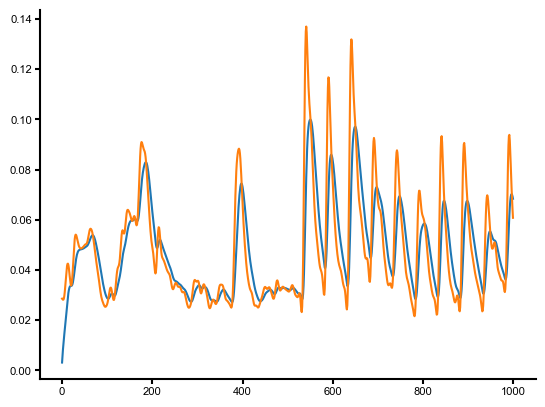

In [21]:
plt.plot(S.flatten())
plt.plot(s_test_block.flatten())

In [33]:
task.seq_periods_eval

[[0, 11250],
 [11250, 12250],
 [12250, 13250],
 [13250, 14250],
 [14250, 15250],
 [15250, 16250],
 [16250, 17250]]

n outliers: 0.008000000000000007


C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_31904\1544987909.py:19: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')


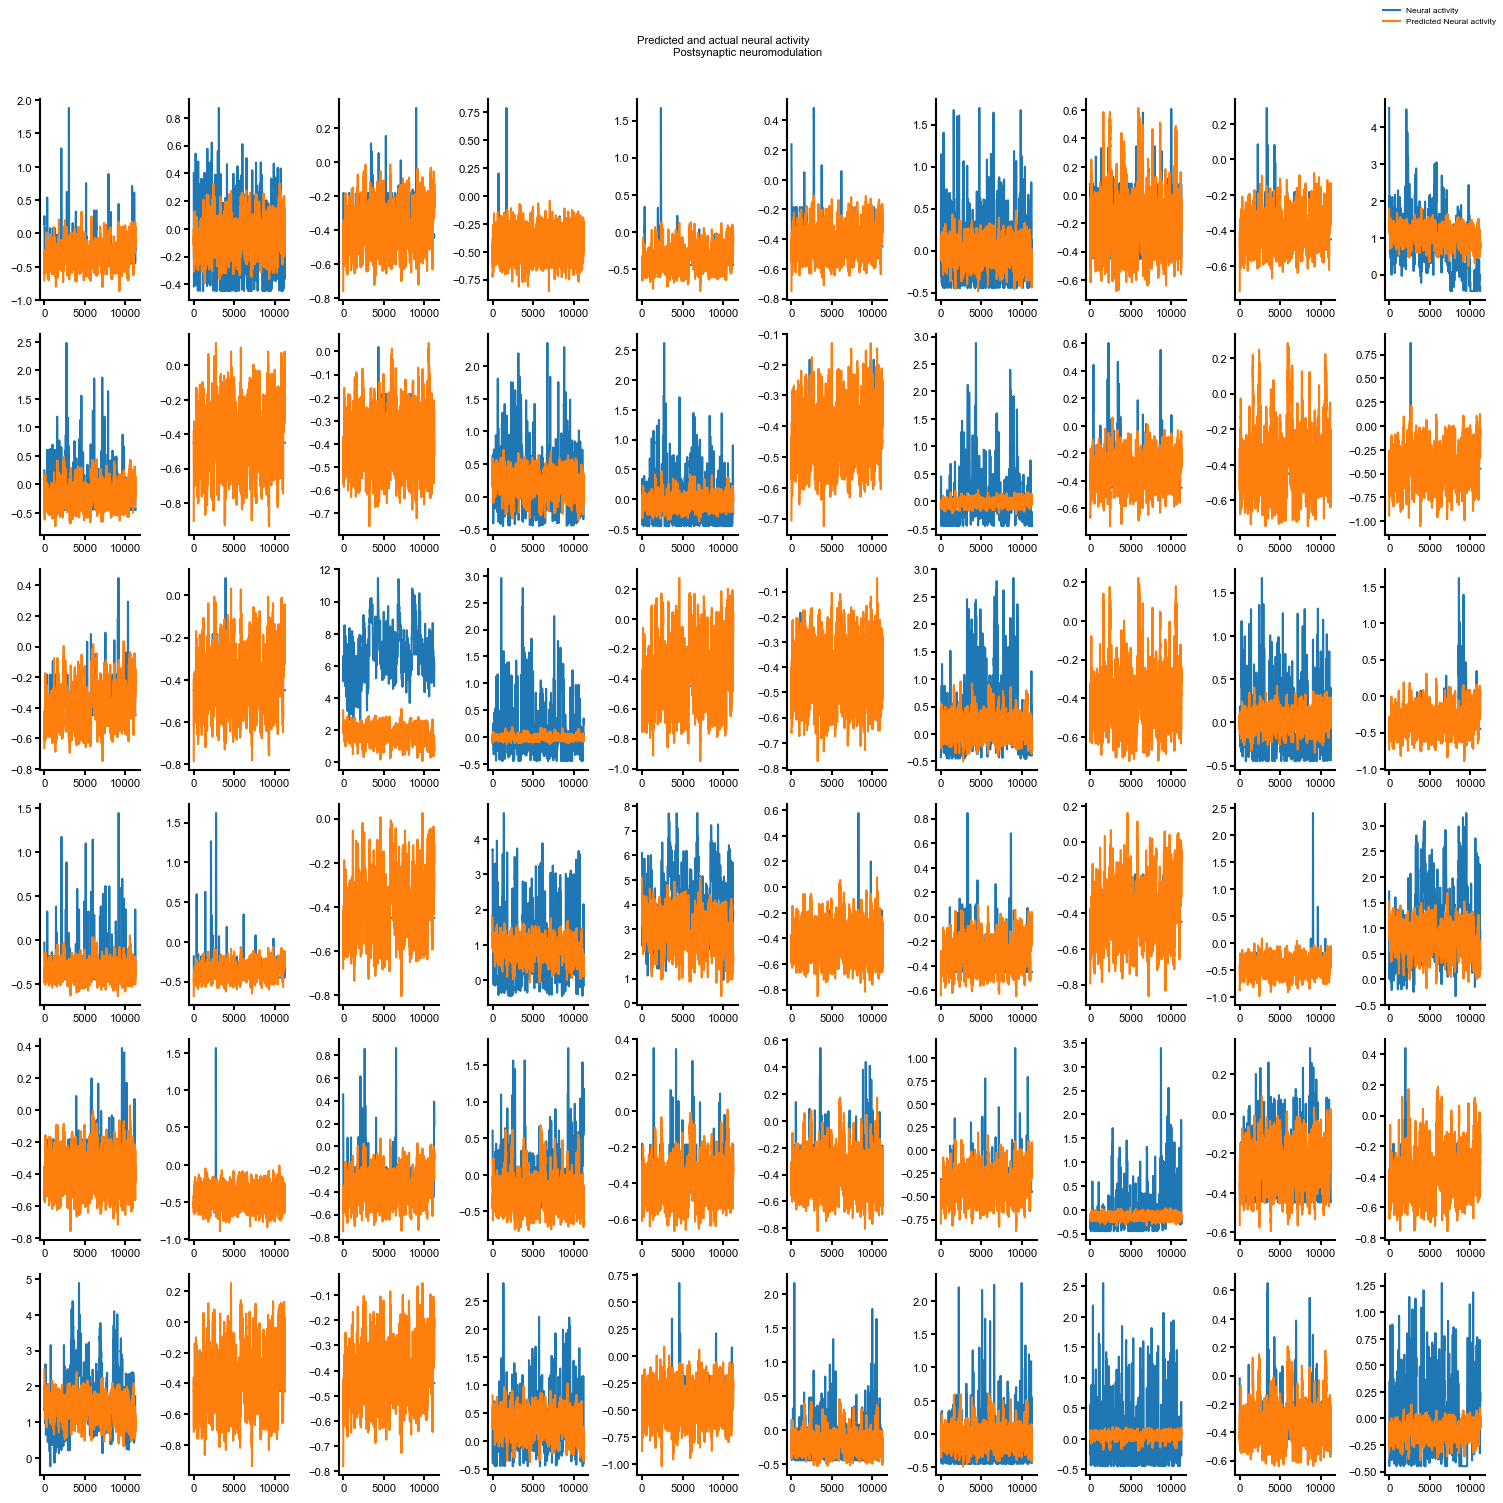

In [43]:
kl_div = []
# for b in range(10):
    # compute the KL-Divergence 
block_idx = 0
model_1 = ('additive', 3, 94, 'gauss', block_idx)
block_start, block_end = task.seq_periods_eval[block_idx]
kl_div_b = compute_KL_divergence(spike_preds[model_1].unsqueeze(0), task.data_eval[block_start:block_end, :].T.unsqueeze(0))
kl_div.append(kl_div_b) 
# plot population activity 
fig, ax = plt.subplots(6, 10, figsize=(15, 15))
idx_i, idx_j = 0, 0
for i in range(60):
    ax[idx_i, idx_j].plot(task.data_eval[block_start:block_end, i], label=f'Neural activity')
    ax[idx_i, idx_j].plot(spike_preds[model_1][i, :].detach(), label=f'Predicted Neural activity')
    idx_j += 1
    if idx_j >= 10: 
        idx_i, idx_j = idx_i + 1, 0
    
fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')
fig.suptitle(f"Predicted and actual neural activity\
                \nPostsynaptic neuromodulation")
plt.tight_layout(rect=[0, 0, 1, 0.97])
    # fig.savefig(f"{figures_dir}/mante postsynaptic rank 2/plot_{b}.png")
    # plt.show()
    
    

In [45]:
from scipy.stats import pearsonr 
pearson_rs = []
for i in range(94):
    pearson_rs.append(pearsonr(spike_preds[model_1][i, :].detach(), task.data_eval[block_start:block_end, i]))
np.array(pearson_rs)

c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\scipy\stats\_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


array([[ 7.21129278e-02,  1.89068460e-14],
       [-4.18656489e-02,  8.91362443e-06],
       [-6.31705362e-02,  1.99756766e-11],
       [-3.61087823e-02,  1.27759328e-04],
       [ 4.99544547e-02,  1.15049680e-07],
       [ 4.25410603e-02,  6.37055014e-06],
       [-8.61436959e-03,  3.60923231e-01],
       [-5.65368760e-02,  1.96378324e-09],
       [ 9.49176343e-02,  6.16692786e-24],
       [ 6.70810756e-02,  1.06175517e-12],
       [-5.95006974e-02,  2.68599505e-10],
       [ 7.20116547e-02,  2.05611031e-14],
       [ 6.45423155e-02,  7.27581826e-12],
       [-3.88944162e-02,  3.68360062e-05],
       [ 1.15236713e-02,  2.21641576e-01],
       [-4.26929270e-03,  6.50708161e-01],
       [ 6.27951753e-02,  2.62380379e-11],
       [ 5.87404462e-02,  4.51614304e-10],
       [            nan,             nan],
       [ 2.39327435e-02,  1.11318531e-02],
       [-1.87187419e-02,  4.71026855e-02],
       [-2.58374019e-02,  6.13227719e-03],
       [-1.23294683e-01,  2.33584181e-39],
       [-5.

In [40]:
kl_div

[14.068832397460938]

n outliers: 0.0040000000000000036


C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_31904\3893181629.py:19: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')


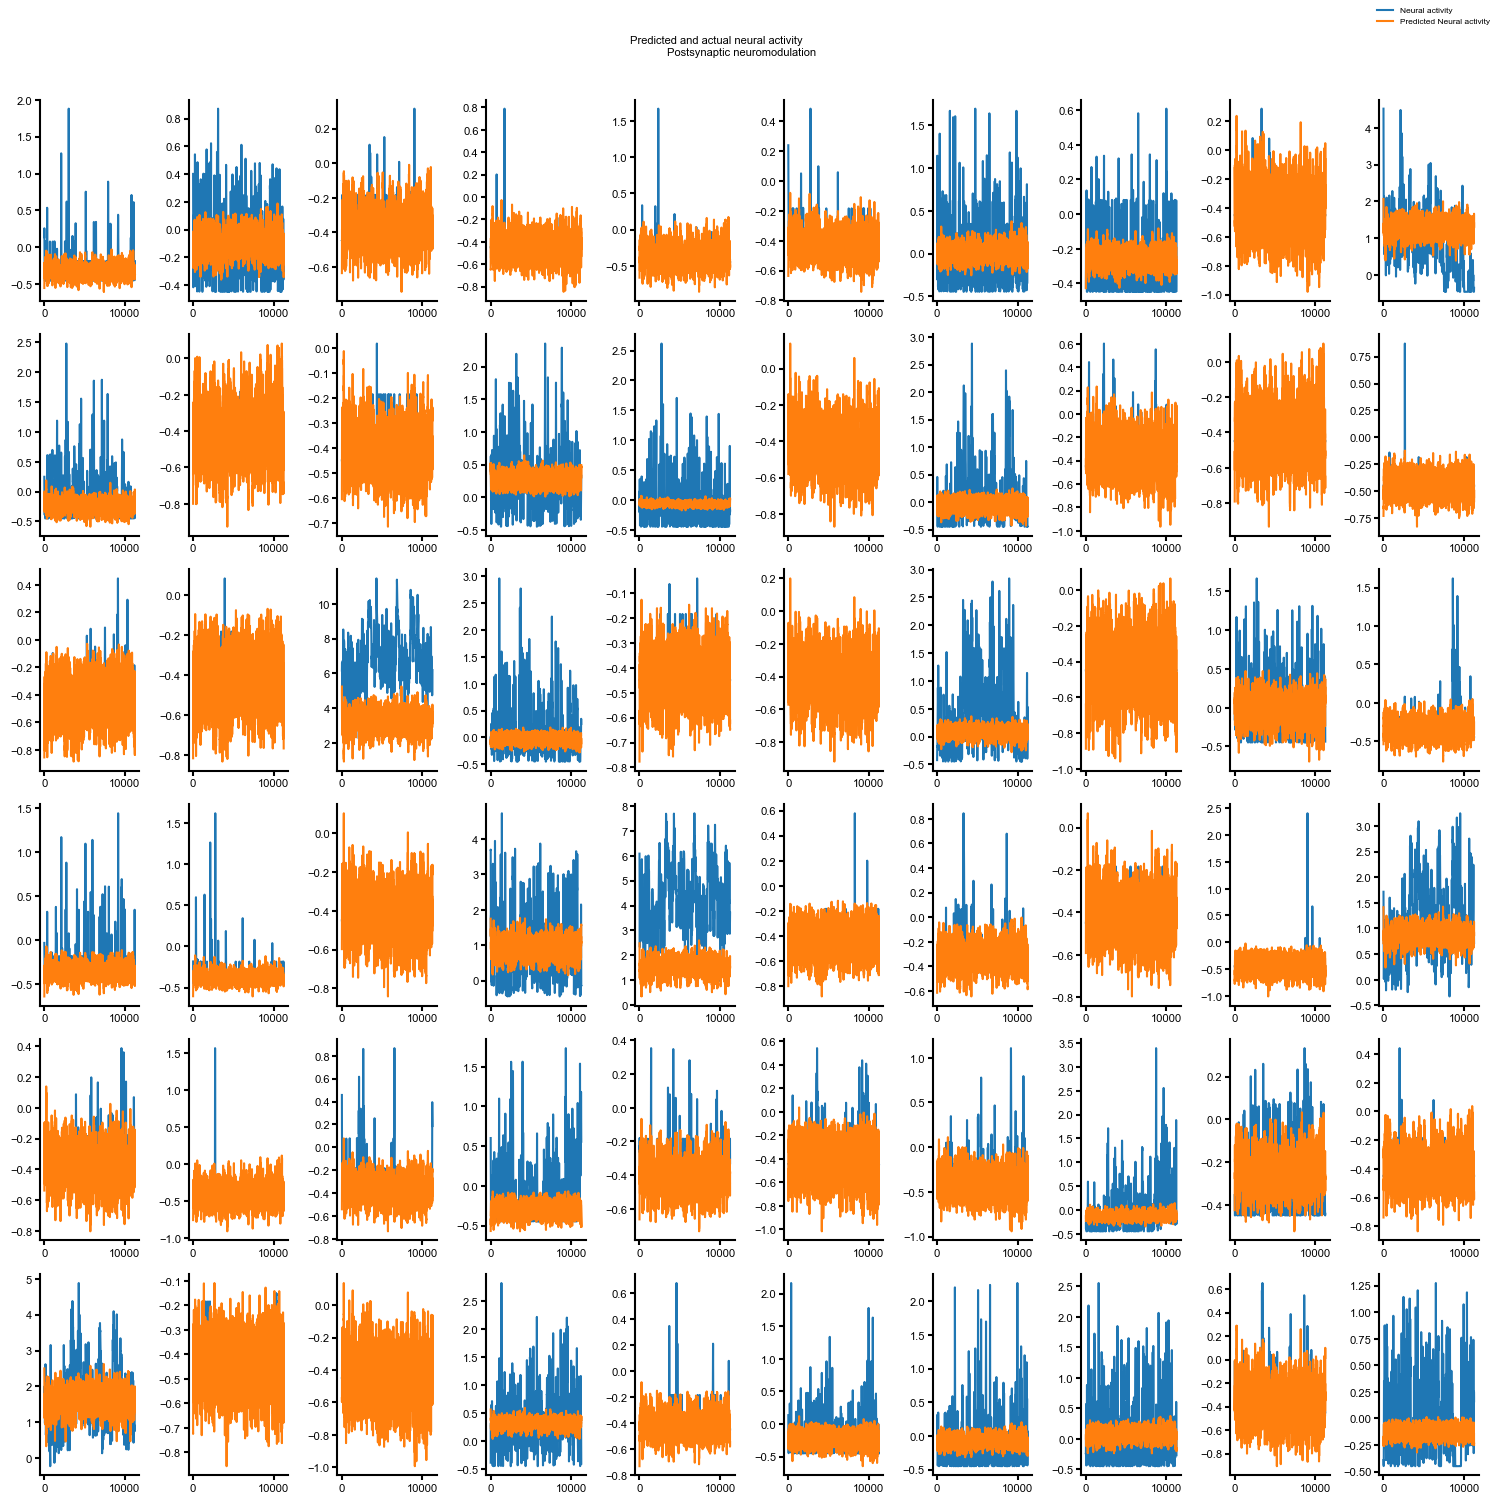

In [46]:
kl_div = []
# for b in range(10):
    # compute the KL-Divergence 
# block_idx = 6
model_2 = ('None', 3, 94, 'gauss', block_idx)
block_start, block_end = task.seq_periods_eval[block_idx]
kl_div_b = compute_KL_divergence(spike_preds[model_2].unsqueeze(0), task.data_eval[block_start:block_end, :].T.unsqueeze(0))
kl_div.append(kl_div_b) 
# plot population activity 
fig, ax = plt.subplots(6, 10, figsize=(15, 15))
idx_i, idx_j = 0, 0
for i in range(60):
    ax[idx_i, idx_j].plot(task.data_eval[block_start:block_end, i], label=f'Neural activity')
    ax[idx_i, idx_j].plot(spike_preds[model_2][i, :].detach(), label=f'Predicted Neural activity')
    idx_j += 1
    if idx_j >= 10: 
        idx_i, idx_j = idx_i + 1, 0
    
fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')
fig.suptitle(f"Predicted and actual neural activity\
                \nPostsynaptic neuromodulation")
plt.tight_layout(rect=[0, 0, 1, 0.97])
    # fig.savefig(f"{figures_dir}/mante postsynaptic rank 2/plot_{b}.png")
    # plt.show()
    
    

In [42]:
kl_div

[10.819864273071289]

C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_26572\2411183948.py:12: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  gaussian_kernel = gaussian(kernel_size, sigma)
C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_26572\2411183948.py:29: RuntimeWarning: invalid value encountered in divide
  conv_gen_1 = (conv_gen_1 - conv_gen_1[:partial_idx].mean()) / conv_gen_1[:partial_idx].std()
C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_26572\2411183948.py:32: RuntimeWarning: invalid value encountered in divide
  conv_test = (conv_test - conv_test[:partial_idx].mean()) / conv_test[:partial_idx].std()
C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_26572\2411183948.py:29: RuntimeWarning: divide by zero encountered in divide
  conv_gen_1 = (conv_gen_1 - conv_gen_1[:partial_idx].mean()) / conv_gen_1[:partial_idx]

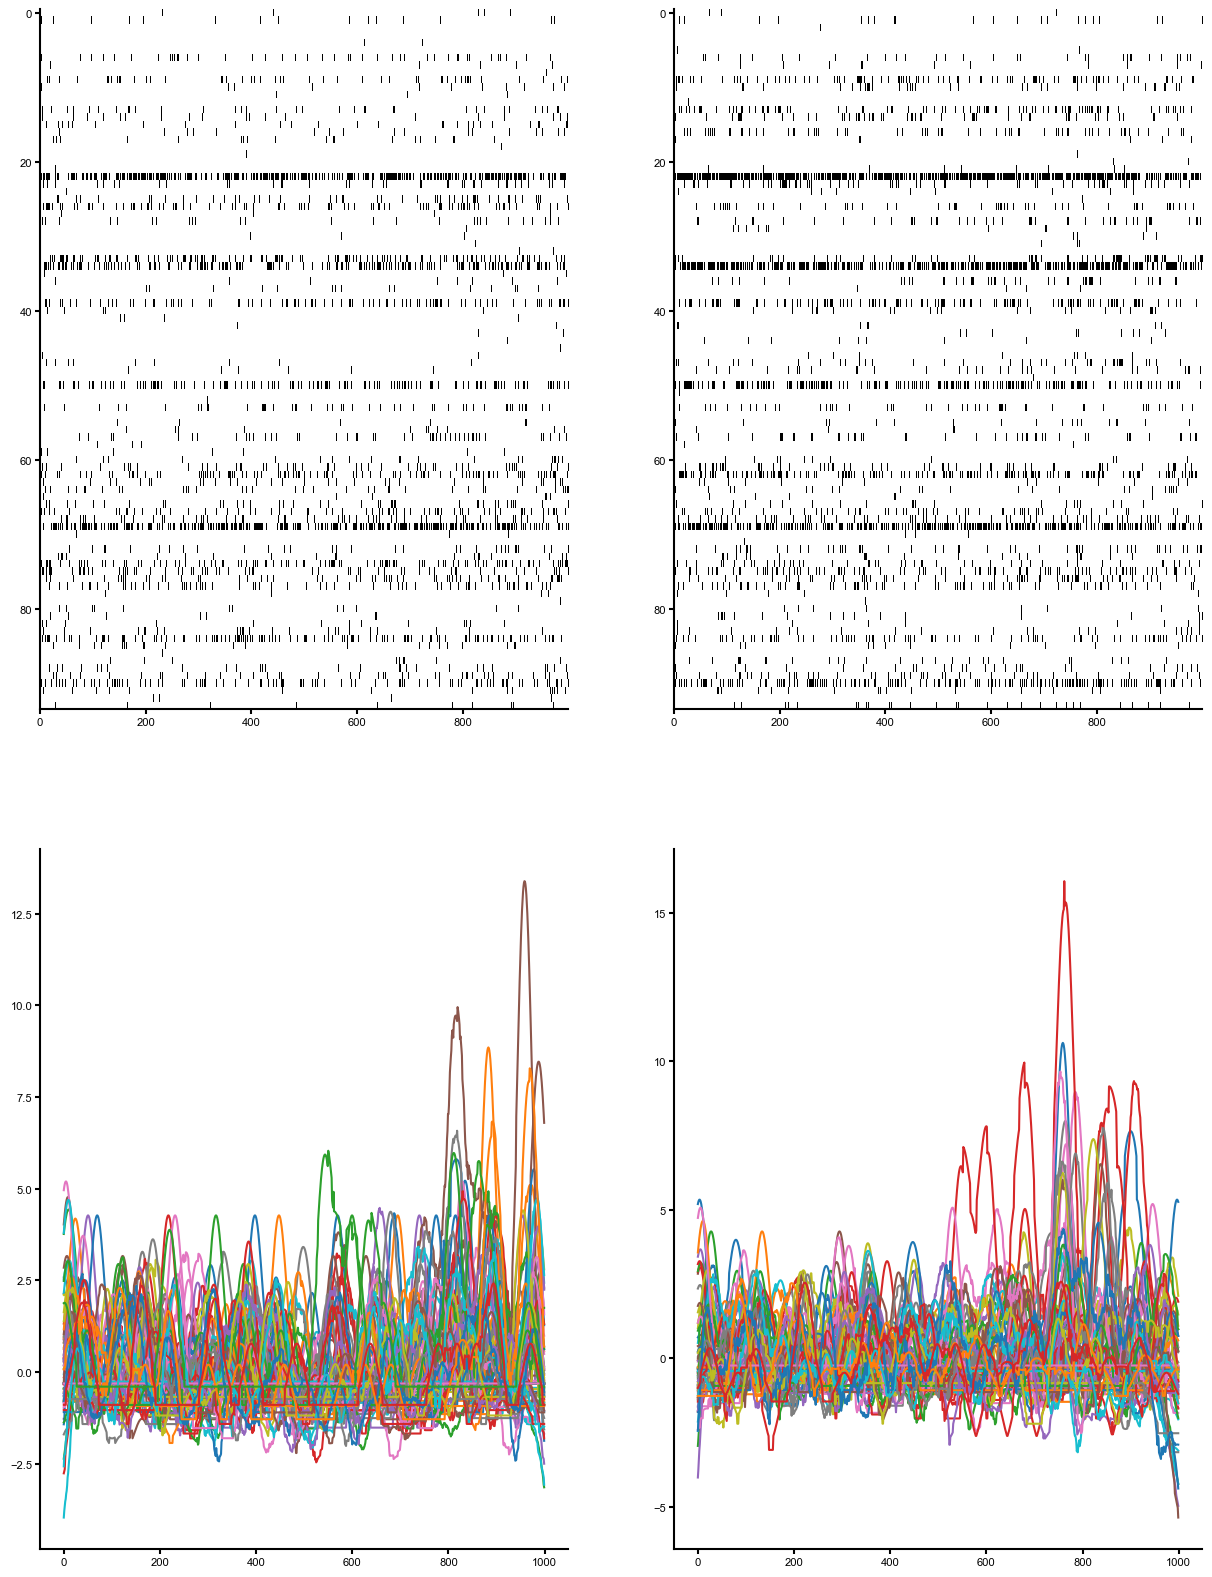

In [21]:
fig, ax = plt.subplots(2, 2, figsize=(15, 20))

block_idx = 4
model_1 = ('additive', 3, 94, '', block_idx)
# model_2 = ('additive', 3, 256, 'unfiltered', block_idx)

block_start, block_end = task.seq_periods_eval[block_idx]

# convolve with a gaussian kernel 
kernel_size = 50 
sigma = 15 
gaussian_kernel = gaussian(kernel_size, sigma) 
gaussian_kernel /= gaussian_kernel.sum() 

ax[0, 0].imshow(spike_preds[model_1].T, aspect='auto', cmap='Greys', interpolation="none", vmax=1)
ax[0, 1].imshow(task.data_eval[block_start:block_end, :].T, aspect='auto', cmap='Greys', interpolation='none', vmax=1)
    
# ax[1, 0].imshow(spike_preds[model_2].T, aspect='auto', cmap='Greys', interpolation="none", vmax=1)
# ax[1, 1].imshow(task.data_eval[block_start:block_end, :].T, aspect='auto', cmap='Greys', interpolation='none', vmax=1)

    # ax[i, 0].set_title(f'Generated Spikes: {model}. Baseline period {i}')
    # ax[i, 1].set_title('Spikes from DTT')
for i in range(model_1[2]): 
    conv_gen_1 = convolve(spike_preds[model_1][:, i], gaussian_kernel, mode='same')
#     conv_gen_2 = convolve(spike_preds[model_2][:, i], gaussian_kernel, mode='same')
    
    conv_test = convolve(task.data_eval[block_start:block_end, i], gaussian_kernel, mode='same') 
    partial_idx = len(conv_gen_1) // 2
    conv_gen_1 = (conv_gen_1 - conv_gen_1[:partial_idx].mean()) / conv_gen_1[:partial_idx].std()
#     conv_gen_2 = (conv_gen_2 - conv_gen_2[:partial_idx].mean()) / conv_gen_2[:partial_idx].std()
    
    conv_test = (conv_test - conv_test[:partial_idx].mean()) / conv_test[:partial_idx].std()

    ax[1, 0].plot(conv_gen_1) 
    ax[1, 1].plot(conv_test)
#     ax[2, 0].axvline(len(conv_gen_1) / 2)
#     ax[2, 1].axvline(len(conv_test) / 2)
#     ax[2, 1].axhline(3)
#     # ax[2, 0].set_ylim([-2, 5])
#     # ax[3, 0].set_ylim([-2, 5])
    
#     ax[3, 0].plot(conv_gen_2) 
#     ax[3, 1].plot(conv_test)    
#     ax[3, 0].axvline(len(conv_gen_2) / 2)
#     ax[3, 1].axvline(len(conv_test) / 2)

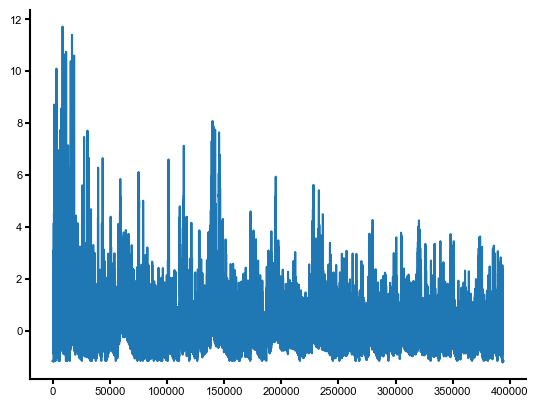

In [22]:
plt.plot(neuromod_activity)

#### 2.2. Compute evaluation metrics between generated and test spikes

In [36]:
from scipy.stats import pearsonr
# Parameters
tau = 4  # Decay time constant

model_vrds = {} # Van Rossum distances 
model_mres = {} # mean-rate errors 
model_isis = {} # model inter-spike interval
num_neurons = 94

for model in spike_preds.keys():
    vrds = np.zeros((num_neurons,))
    mres = np.zeros_like(vrds) 
    block_idx = model[-1] 
    block_start, block_end = task.seq_periods_eval[block_idx]
    T = block_end - block_start 
    for j in range(num_neurons):
        vrd = van_rossum_distance(spike_preds[model][:, j], task.data_eval[block_start:block_end, j], tau, T) 
        
        vrds[j] = vrd 
        # mean_rates_gen = spike_preds[model][:, j].sum() / (bin_size * T) 
        # mean_rates_test = task.data_eval[block_start:block_end, j].sum() / (bin_size * T)
        # mre = np.abs(mean_rates_gen - mean_rates_test) 
        # mres[j] = mean 
    mres = mean_rate(spike_preds[model].T.numpy(), task.data_eval[block_start:block_end, :].T.numpy())
    _, isi_stats_gen, _ = calc_isi_stats(spike_preds[model]) 
    _, isi_stats_test, _ = calc_isi_stats(task.data_eval[block_start:block_end, :])
    isi_stats_gen = np.nan_to_num(isi_stats_gen)
    isi_stats_test = np.nan_to_num(isi_stats_test)

    # mean_corr = pearsonr(isi_stats_gen, isi_stats_test)[0]
    isi_err = np.abs(isi_stats_gen - isi_stats_test).sum()
    model_vrds[model] = (vrds.sum())
    model_mres[model] = (mres.sum()) 

    print(f'{model}: VRD: {model_vrds[model]}, MRE: {model_mres[model]}, ISI mean corr: {isi_err}')

c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


('None', 3, 94, '', 0): VRD: 849.644527466372, MRE: 33.412953389830506, ISI mean corr: 53418.90476836901
('None', 3, 94, '', 1): VRD: 211.17560996804735, MRE: 3.817095703125, ISI mean corr: 4684.155539849698
('None', 3, 94, '', 2): VRD: 208.28136581305745, MRE: 2.395680908203125, ISI mean corr: 4453.029838932121
('None', 3, 94, '', 3): VRD: 206.79173824491258, MRE: 1.38625537109375, ISI mean corr: 4804.2759892357735
('None', 3, 94, '', 4): VRD: 216.8499247675614, MRE: 2.06544677734375, ISI mean corr: 4426.003703007545
('None', 3, 94, '', 5): VRD: 235.0122033274381, MRE: 4.3088828125, ISI mean corr: 4190.364738666703
('None', 3, 94, '', 6): VRD: 239.57260155586533, MRE: 4.159904296875, ISI mean corr: 5005.200543262952
('None', 3, 256, '', 0): VRD: 842.6342444353043, MRE: 23.85456991525424, ISI mean corr: 37971.50897637075
('None', 3, 256, '', 1): VRD: 217.6177294046342, MRE: 2.50324462890625, ISI mean corr: 4466.531452533483
('None', 3, 256, '', 2): VRD: 213.145893668233, MRE: 0.7269574

In [33]:
model = ('additive', 3, 94, '', block_idx)
_, isi_stats_gen, _ = calc_isi_stats(spike_preds[model]) 
_, isi_stats_test, _ = calc_isi_stats(task.data_eval[block_start:block_end, :])
isi_stats_gen = np.nan_to_num(isi_stats_gen)
isi_stats_test = np.nan_to_num(isi_stats_test)


c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


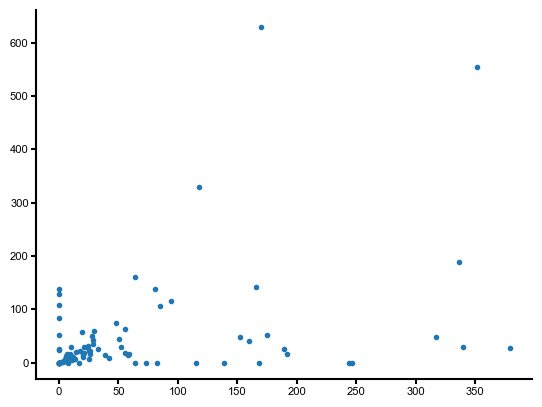

In [34]:
plt.scatter(isi_stats_gen, isi_stats_test)

#### 2.3. Compute the log-likelihood of the test data under models

In [31]:
ll_xs = {}

ll_x_func = (
    lambda x, mu: torch.distributions.Poisson(mu)
    .log_prob(x)
    .sum()
)

for model in models.keys():
    # if model[2] != 94 and model[2] != 95: continue 
    vae = models[model]
    neuromod = model[0]
    for i, block in enumerate(task.seq_periods_eval):
        block_start = block[0]
        block_end = block[1]
        T = block_end - block_start 
        sim_s, s_test_block = False, None 
        if neuromod != 'None':
            s_test_block = task.s_test[:, block_start:block_end].unsqueeze(0)
        if neuromod != 'None': sim_s = True 
        _, _, _, _, _, _, ll, _ = vae.forward_VGTF(task.data_eval[block_start:block_end, :].T.unsqueeze(0), 
                                                   s=s_test_block, 
                                                   sim_s=sim_s, 
                                                   sim_v=False, 
                                                   out_likelihood='Poisson',
                                                   resample='systematic', 
                                                   u=torch.zeros((1, 0, task.data_eval.shape[0])))
        print(model, i, ll)

('None', 3, 94, '') 0 tensor([-18.4398])
('None', 3, 94, '') 1 tensor([-19.8265])
('None', 3, 94, '') 2 tensor([-17.7927])
('None', 3, 94, '') 3 tensor([-17.8362])
('None', 3, 94, '') 4 tensor([-19.6290])
('None', 3, 94, '') 5 tensor([-20.3490])
('None', 3, 94, '') 6 tensor([-21.0946])
('additive', 3, 94, '') 0 tensor([-18.9990])
('additive', 3, 94, '') 1 tensor([-20.0892])
('additive', 3, 94, '') 2 tensor([-17.7171])
('additive', 3, 94, '') 3 tensor([-17.8194])
('additive', 3, 94, '') 4 tensor([-19.8007])
('additive', 3, 94, '') 5 tensor([-20.6681])
('additive', 3, 94, '') 6 tensor([-21.4749])
('additive', 3, 94, '_deconvolved') 0 tensor([-18.7202])
('additive', 3, 94, '_deconvolved') 1 tensor([-19.8045])
('additive', 3, 94, '_deconvolved') 2 tensor([-17.6760])
('additive', 3, 94, '_deconvolved') 3 tensor([-17.7565])
('additive', 3, 94, '_deconvolved') 4 tensor([-19.7207])
('additive', 3, 94, '_deconvolved') 5 tensor([-20.5088])
('additive', 3, 94, '_deconvolved') 6 tensor([-21.2015])

KeyboardInterrupt: 

#### Compare PSTH of each model around airpuff trials

In [35]:
spike_preds[('additive', 3, 94, 'deconvolved', 0)].shape

torch.Size([7375, 94])

In [19]:
def get_bins(spike_preds, t, window_size):
    # get binned spike counts centered at time t
    # get bin index 
    bin_idx = t / bin_size 
    return spike_preds[bin_idx - window_size:bin_idx + window_size]

In [20]:
def get_psth(bins, bin_size_psth = 20):
    t = bins.shape[0] // 2
    print(t, bins.shape)
    # re-bin to the desired bin size 
    # hist_left = [bins[i:i + bin_size_psth, :].sum(axis=0) for i in range(t - bin_size_psth, 0, -bin_size_psth)]
    hist_right = [bins[i:i + bin_size_psth:].sum(axis=0) for i in range(0, bins.shape[0] - bin_size_psth, bin_size_psth)]
    # print(len(hist_left), len(hist_right))
    # psth = np.hstack([hist_left, hist_right])
    return np.array(hist_right)
    return psth 

In [21]:
airpuff_trial_times

[145744, 148534, 151322, 191356, 194143, 196935]

In [77]:
neuromod, rank, N, filtered, block_idx = 'additive', 3, 512, 'unfiltered', 3
model1 = (neuromod, rank, N, filtered, block_idx)
model2 = ('None', rank, N, filtered, block_idx)
psth_model_1 = get_psth(spike_preds[model1])
psth_model_2 = get_psth(spike_preds[model2])
block_start, block_end = task.seq_periods_eval[block_idx]
psth_test = get_psth(task.data_eval[block_start:block_end, :])

500 torch.Size([1000, 94])
500 torch.Size([1000, 94])
500 torch.Size([1000, 94])


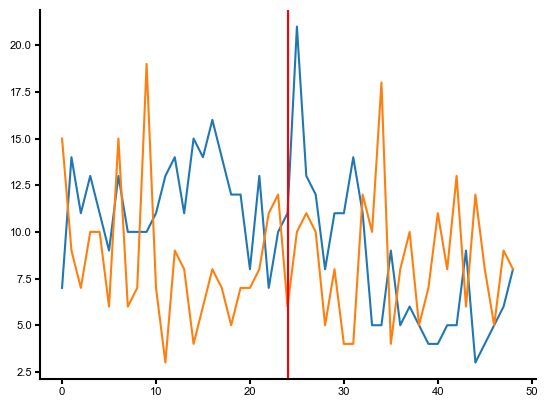

In [98]:
neur_idx = 34
plt.plot(psth_test[:, neur_idx])
plt.plot(psth_model_1[:, neur_idx])
center = len(psth_test[:, neur_idx]) // 2 
plt.axvline(center, c='r')

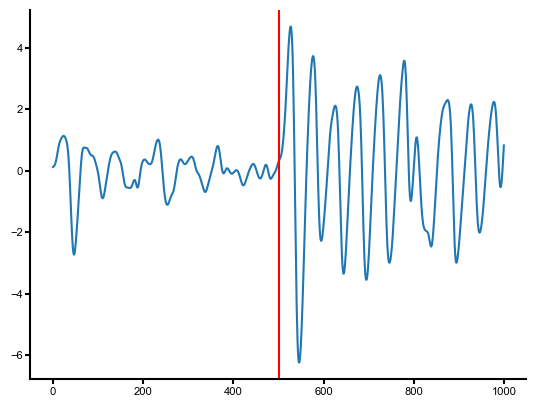

In [97]:
plt.plot(task.s_test[0, block_start:block_end])
plt.axvline(500, color='r')

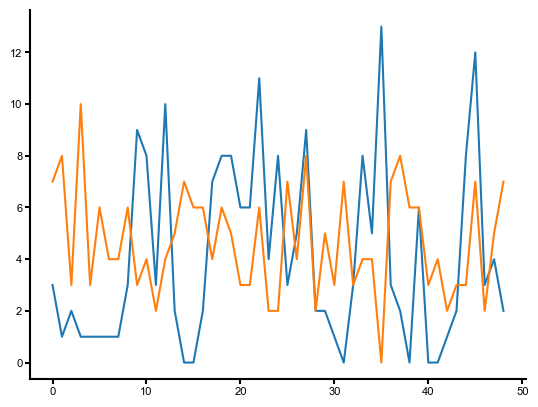

In [85]:
neur_idx = 33
plt.plot(psth_test[:, neur_idx])
plt.plot(psth_model_2[:, neur_idx])


### Compare models per trial block

In [85]:
dataloader = DataLoader(
        task, batch_size=256, shuffle=True
    )
data_sample = next(iter(dataloader)) 
inputs, stim, s = data_sample
sim_s = False 
s = None 
ll, _, _, _, _, _, _, _ = models[('no_neuromodulation', 3, 512)].forward_VGTF(inputs, s=s, sim_s=sim_s, sim_v=False, resample='systematic', u=stim)

In [86]:
ll.mean().item()

-120.94171905517578

In [77]:
test = task.data[t_start:t_start + 100, :].T.unsqueeze(0)
s_block = task.s_train[:, t_start:t_start+100]
models[('additive', 3, 95)].eval()
loss, _, _, _, _, _, ll, _ = models[('additive', 3, 95)].forward_VGTF(test, s=s_block.unsqueeze(0), sim_s=True, sim_v=False, resample='systematic', u=torch.zeros((1, 0, task.data_eval.shape[0])))
ll, loss 

(tensor([-95.5780]), tensor([-95.5780], grad_fn=<MeanBackward1>))

In [31]:
from scipy.stats import pearsonr
pearsonr(weights1.flatten(), weights2.flatten())

PearsonRResult(statistic=0.19128293795482826, pvalue=0.06477095998975796)

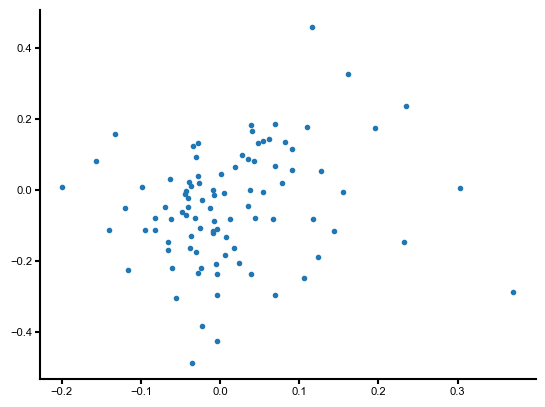

In [28]:
weights1 = models[('additive', 3, 94, 'deconvolved')].rnn.transition.A.detach()
weights2 = models[('additive', 3, 94, 'calcium')].rnn.transition.A.detach()

plt.scatter(weights1, weights2)

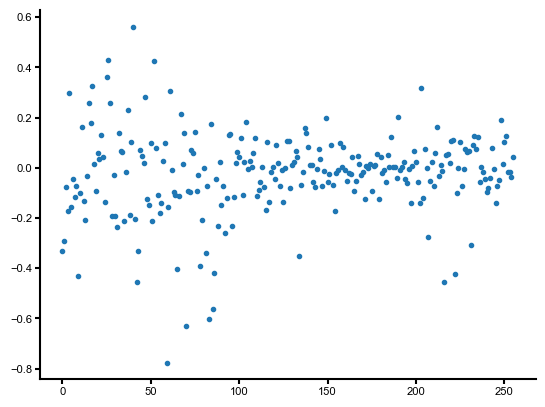

In [88]:
plt.scatter(np.arange(0, models[('additive', 3, 256)].rnn.transition.A.shape[0]), models[('additive', 3, 256)].rnn.transition.A.detach())

In [33]:
lmd.shape, data_eval.shape

(torch.Size([81, 7500]), torch.Size([7500, 81]))

In [36]:
mean_rate_errors.sum(axis=1), mean_rate_errors.mean(axis=1)

(array([156.72542383, 158.61695064]), array([1.93488178, 1.95823396]))

### Compute log likelihood of test data under models

In [80]:
test_samples.shape

(111, 33750)

In [ ]:
data_eval = torch.from_numpy(test_samples.T).to(torch.float32)[start_latent:T, :]
for neuromod in neuromodulation: 
    for rank in [1, 2, 3, 4]:
        vae = models[(neuromod, rank)]
        z_hat, _, _, _ = vae.encoder(data_eval.T.unsqueeze(0))
        lmd = vae.rnn.get_observation(z_hat, noise_scale=0)[0, :, :, 0]
        

### Plot latent activity of Rank 2 network

In [79]:
z_hat, _, _, _ = models[1].encoder(data_eval.T.unsqueeze(0))
# z0 = z_hat[:, :, :1].squeeze() 
z0 = torch.tensor([-59, 10]).to(torch.float32)
Z = models[1].rnn.get_latent_time_series(time_steps=T, cut_off=1000, z0=z0, noise_scale=1.0, sim_v=False)
# Z = Z.reshape(-1, 2)

no input


Text(0.5, 1.0, 'Latent trajectory for predictions over test set')

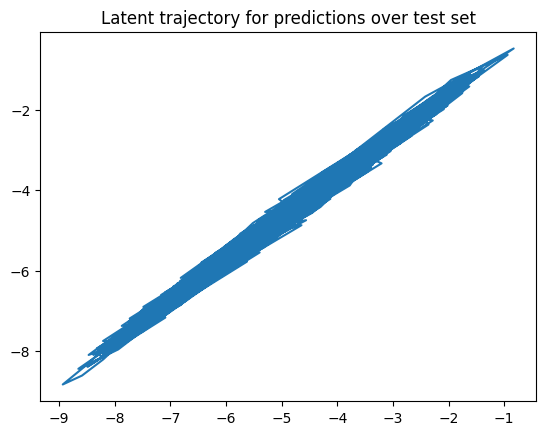

In [ ]:
plt.plot(Z[0, 0, :, 0], Z[0, 1, :, 0])
plt.title('2D Latent trajectory for predictions over test set')

Text(0.5, 1.0, 'Latent trajectory for predictions over test set')

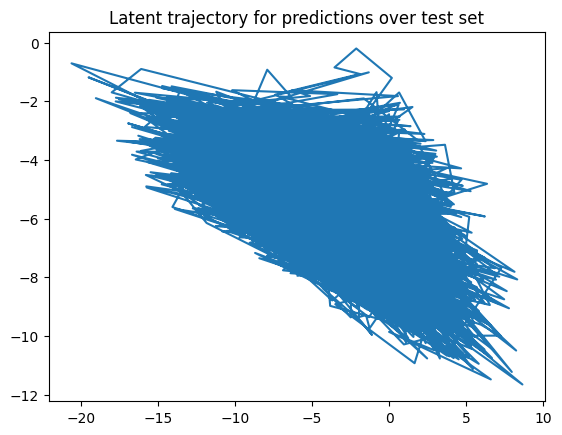

In [85]:
z_hat = z_hat.detach()
plt.plot(z_hat[0, 0, :, 0], z_hat[0, 1, :, 0])
plt.title('Latent trajectory for predictions over test set')

### Plot latent trajectory of Rank 3 model

In [87]:
z_hat, _, _, _ = models[2].encoder(data_eval.T.unsqueeze(0))
z0 = z_hat[:, :, :1].squeeze() 
# z0 = torch.tensor([-59, 10]).to(torch.float32)
Z = models[2].rnn.get_latent_time_series(time_steps=T, cut_off=1000, z0=z0, noise_scale=1.0, sim_v=False)
# Z = Z.reshape(-1, 2)

no input


Text(0.5, 0.92, '3D Latent trajectory')

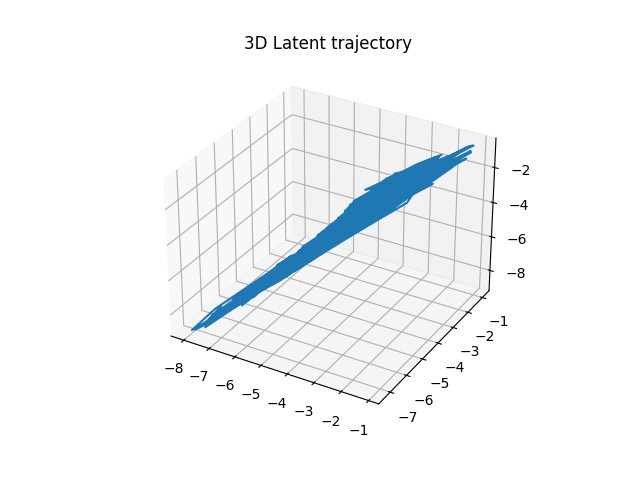

In [90]:
%matplotlib ipympl
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(Z[0, 0, :, 0], Z[0, 1, :, 0], Z[0, 2, :, 0])
ax.set_title('3D Latent trajectory')